# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/20Aarya05/FlyrankAI_1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The playbook ranks content for review based on a predicted decline probability from our Random Forest model, supplemented with business logic.

- **Priority 1: High-Risk Mature Content** (Age > 180 days, high decline probability). Action: Refresh. Reason: The model observed that stale content declines sharply but can recover with updates.
- **Priority 2: High-Risk Thin Content** (Word count < 1000, high decline probability). Action: Expand. Reason: The data showed that expanding thin but visible pages improves their trajectory.
- **Priority 3: Monitor** (Stable predictions). Action: Hold. Reason: Resource optimization.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

num_features = ['search_volume', 'cpc', 'word_count', 'char_count', 'content_age_days',
                'days_since_last_update', 'avg_position', 'engagement_rate']
cat_features = ['competition_level', 'content_type', 'main_intent']

X = df[num_features + cat_features]
y = df['is_declining_label']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, max_depth=10, n_estimators=100))
])
model.fit(X, y)

# Generate predictions
df['decline_probability'] = model.predict_proba(X)[:, 1]

# Action rules
def assign_action(row):
    if row['decline_probability'] > 0.6:
        if row['content_age_days'] > 180:
            return 'Refresh (High-Risk Mature)'
        elif row['word_count'] < 1000:
            return 'Expand (High-Risk Thin)'
        else:
            return 'Review Targeting'
    return 'Hold (Stable)'

df['recommended_action'] = df.apply(assign_action, axis=1)
queue = df[df['recommended_action'] != 'Hold (Stable)'].sort_values('decline_probability', ascending=False)
queue[['content_id', 'decline_probability', 'recommended_action', 'content_age_days', 'word_count']].head()

,content_id,decline_probability,recommended_action,content_age_days,word_count
5719,content_174c900f8348,0.918928,Review Targeting,169,3996.0
6973,content_996deba6cd11,0.912122,Review Targeting,169,3954.0
23268,content_b63d4f43a84b,0.911848,Review Targeting,169,3986.0
26035,content_75fb1c72a2c3,0.911833,Review Targeting,169,3971.0
25108,content_5a467b5c7648,0.911833,Review Targeting,169,3977.0


## 2. Intended use and limits

**Intended Use**: This queue acts as a decision-support tool to prioritize the content team's editorial calendar. It surfaces pages where an update is associated with better outcomes in the dataset.

**Limits**: This is an observational model. The probabilities do not prove that an update will guarantee growth, only that similar pages historically showed improvement when updated. The scores are directional guidance, not automated publishing triggers.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

**Human Review**: Editors must manually verify that the page actually requires updating (e.g. outdated facts, thin sections) before spending resources.

**No-Go List**:
- Do not blindly automate content expansion using language models without editorial review.
- Do not apply 'Refresh' actions to compliance or legally locked pages.
- Do not rely entirely on the model for seasonal content, which drops naturally outside of its season.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

**Monitoring**: Track the actual 30-day impression changes for the pages updated based on this queue against a holdout group.

**Retrain Triggers**:
- If the click-through rate of refreshed pages fails to improve over a 3-month rolling window.
- If major search algorithm updates alter the baseline distribution of visibility.
- Scheduled quarterly retraining to capture new seasonality and trend data.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported to work/outputs/action_queue.csv
Figure exported to work/figures/action_distribution.png


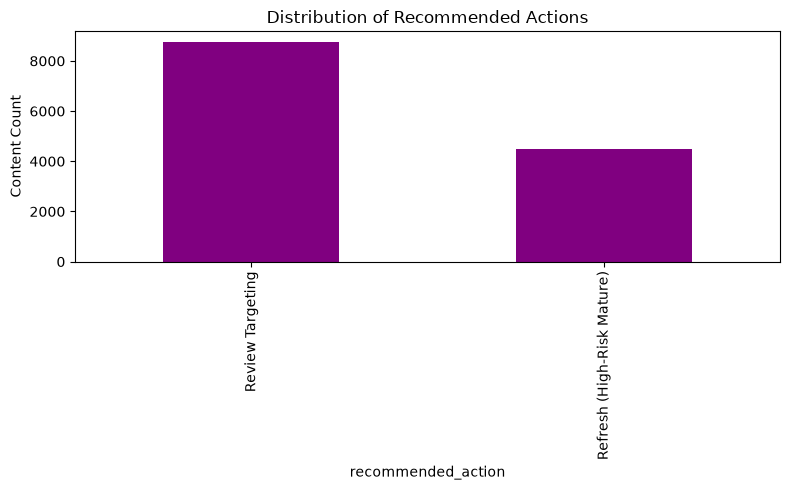

In [5]:
import os
import matplotlib.pyplot as plt

os.makedirs('../../work/outputs', exist_ok=True)
os.makedirs('../../work/figures', exist_ok=True)

queue.to_csv('../../work/outputs/action_queue.csv', index=False)
print("Queue exported to work/outputs/action_queue.csv")

plt.figure(figsize=(8,5))
queue['recommended_action'].value_counts().plot(kind='bar', color='purple')
plt.title('Distribution of Recommended Actions')
plt.ylabel('Content Count')
plt.tight_layout()
plt.savefig('../../work/figures/action_distribution.png')
print("Figure exported to work/figures/action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.